# Module 03: EDA

In [2]:
# packages
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from sklearn.model_selection import train_test_split 
from ISLP import load_data

# set seed
seed = 2323

### We'll use the _Hitters_ data from ISLP for this activity. The metadata for _Hitters_ can be found [here](https://intro-stat-learning.github.io/ISLP/datasets/Hitters.html).

In [3]:
# Load the data
Hitters = load_data('Hitters')

### Determine the number of rows and columns in the dataset by returning its "shape" attribute

In [4]:
Hitters.shape

(322, 20)

### Determine whether each feature is numeric or categorical by returning the "dtype" attribute for each column

In [5]:
for col in Hitters.columns:
    Hitters.dtypes

### Before doing any other analyses, let's create training and test sets.

In [6]:
Train, Test = train_test_split(Hitters, 
                               random_state=seed, 
                               test_size=0.40, 
                               shuffle=True) 

### Based on the metadata, what is the difference between the 6 columns starting with 'C' and the 6 related columns that don't?

C shows the carrer totals for all stats and without the C it shows stats only from the 1986 season.

### On the training set, create pairwise scatterplots for each of these 6 columns with the 'Salary' variable.

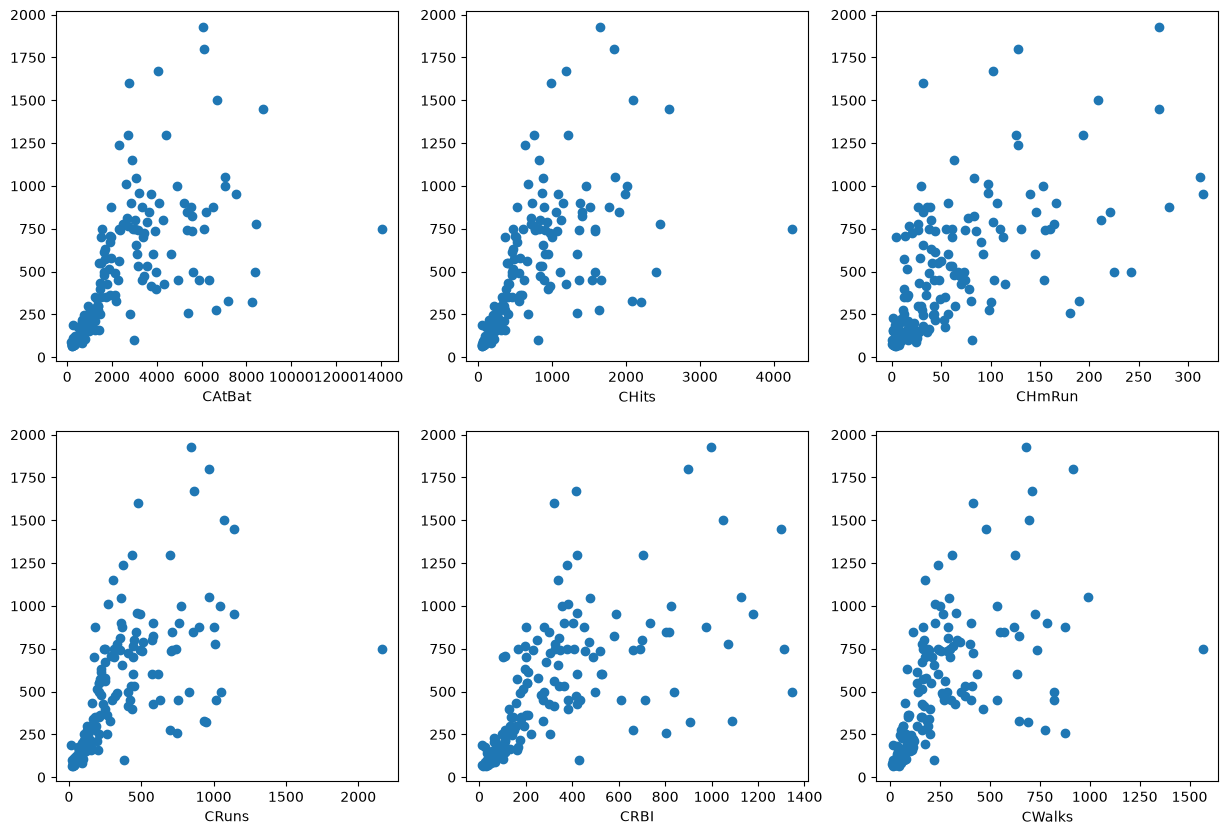

In [7]:
# First create a subset of the columns that we want to plot

subset = Train[['CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks']]

# Initialize the plots before drawing them

fig, axes = subplots(nrows=2,
                     ncols=3,
                     figsize=(15, 10))
# Copy the helper function

def range_to_grid(i,Ncol):
    x=[]
    y=[]
    for n in range(Ncol**2):
        x.append(int(np.floor(n/Ncol)))
        y.append(n % Ncol)
        #print(n,x[n],y[n])
    return x[i],y[i]

# Plot the variables

for j in range(len(subset.columns)):
    axes[range_to_grid(j,3)[0],range_to_grid(j,3)[1]].plot(subset.iloc[:,j], Train['Salary'], 'o')
    axes[range_to_grid(j,3)[0],range_to_grid(j,3)[1]].set_xlabel(subset.columns[j])


### Use the "describe" method to determine the mean, standard deviation, and 5 number summary of all numeric variables in the training subset of _Hitters_.

In [8]:
numeric_summary = Hitters.describe().T

### It looks like the mean and median of 'AtBat' are nearly equal. This _might_ suggest that this variable is normally distributed. Create a histogram of 'AtBat' to check this hypothesis.

Text(0, 0.5, 'Count')

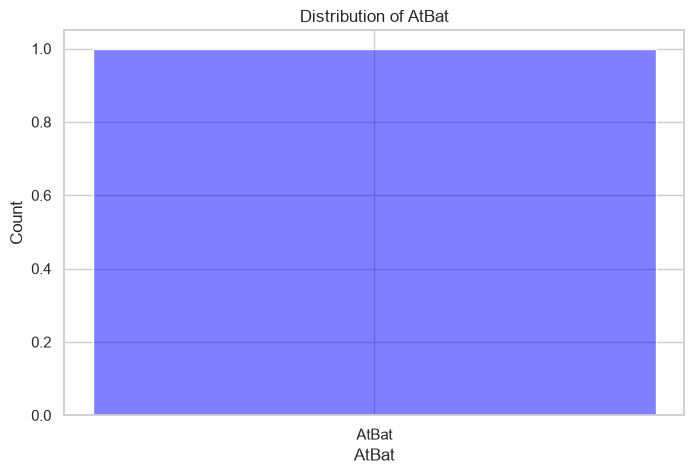

In [9]:
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.histplot(data='AtBat',kde=True, bins=20, color='blue', alpha=0.5)
plt.title('Distribution of AtBat')
plt.xlabel('AtBat')
plt.ylabel('Count')

### Let's standardize the AtBat feature (i.e., normalize by z-scores). We'll create a new column in the training data called 'AtBat_st' to represent this.

In [10]:
mean_atbat = Hitters['AtBat'].mean()
std_atbat = Hitters['AtBat'].std()
Hitters['AtBat'] = (Hitters['AtBat'] - mean_atbat) / std_atbat
print(Hitters['AtBat'].head())

0   -0.573179
1   -0.429768
2    0.639298
3    0.750115
4   -0.390656
Name: AtBat, dtype: float64


### How many rows have an 'AtBat' value within the first standard deviation?

Hint: the 'len' magic method returns the number of rows of a dataFrame.

In [11]:
mean = Hitters['AtBat'].mean()
std = Hitters['AtBat'].std()
lower_bound = mean - 3 * std
upper_bound = mean + 3 * std
n_1std = len(Hitters[(Hitters['AtBat'] < lower_bound) | (Hitters['AtBat'] > upper_bound)])

### Going back to the results of the 'describe' method, how can you tell that the 'Salary' variable has missing values?

The describe method counts the stats by only showing the valid entires. If the count for the salary method is lower than all the numbers in rows of data then it will show the missing data represents the invalid entries.

### Describe a situation where a variable could have missing values but this would not be reflected in the results of the 'describe' method.

This happens when the missing values are encoded using placeholder values instead of the invalid entries.Since these placeholders are valid datasets they are looked at as normal entries.

### On the training data, create separate boxplots of the 'AtBat' variable for when 'Salary' is populated or missing.

Text(0.5, 0, 'Salary Missing (0 = No, 1 = Yes)')

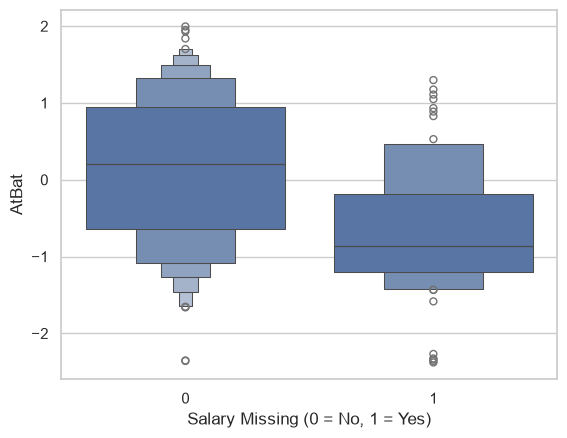

In [13]:
Hitters['Salary_Missing'] = Hitters['Salary'].isnull().astype(int)
sns.boxenplot(x='Salary_Missing', y='AtBat', data=Hitters)
plt.xlabel("Salary Missing (0 = No, 1 = Yes)")

### Create a correlation matrix for all numeric features in the training set

In [15]:
correlation_matrix = Hitters.select_dtypes(include=[np.number]).corr()

### Propose two different ways of imputing the missing values of Salary while taking advantage of the information given in the boxplots or the correlation matrix.

### For our last exercise, we'll explore Hits and Walks relative to AtBat totals. 
- Use the sum function to calculuate the totals of each of these three variables for the 1986 season (on the training set). 
- Create a pie chart which shows total hits, total walks, and remaining total (neither) as percents of the At Bats total (on the training set). 

In [21]:
TotHits =Hitters['Hits'].sum()
TotWalks =Hitters['Walks'].sum()
TotAtBat =Hitters['AtBat'].sum()

Labels = ['Hits', 'Walks', 'Neither']
Totals = [TotHits, TotWalks, TotAtBat-TotHits-TotWalks]
plt.figure(figsize=(8, 5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

ValueError: Wedge sizes 'x' must be non negative values

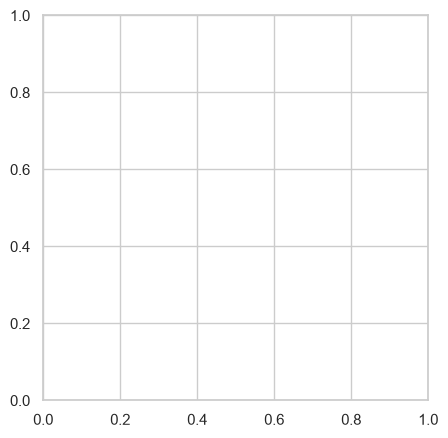

In [23]:
plt.figure(figsize=(8, 5))
plt.pie(Totals, labels=Labels, autopct='%1.1f%%', startangle=80)
plt.title('Proportion of Hits, Walks, and Neither')
plt.show()
        


### The previous two cells gave us totals across all players. For each player in the training set, calculate the Hits as a percent of AtBat and store it in a new variable called 'AVG'

In [ ]:

Hitters[AVG] = Hitters['Hits'] / Hitters['AtBat'] * 100


NameError: name 'AVG' is not defined

### Using 0.25 and 0.31 as the split points, create a new variable with three bins: high, medium, and low. 

In [34]:
Train['AVG_bin'] = 'medium'
Train.loc[Hitters['AVG'] < 0.25, 'AVG_bin'] = 'low'
Train.loc[Hitters['AVG'] > 0.31, 'AVG_bin'] = 'high'

KeyError: 'AVG'

### Create a bar chart that displays the number of players in each of the low, medium, and high categories (for the training data).

In [ ]:
Train['AVG_bin'].value_counts()

Notice that the order of the bars will be medium, low, high. That's counterintuitive. We can reorder these quickly. 

In [ ]:
indexMap = ['low', 'medium', 'high']
reordered_list = [Train['AVG_bin'].value_counts()[i] for i in indexMap]

In [ ]:
plt.bar(#fillin

plt.title("1986 AVG (Training Set)")
plt.ylabel("Number of Players")

plt.xticks(#fillin

plt.show()

### Did we use the depth method or width method for creating these bins? Explain.

#fillin Type your answer here.